#🚦 Road Accident Severity Prediction
# Dataset: Accidents Classified According to Road Environment (MoRTH, India 2017–2023)  
# Goal: Predict Severity — Low / Medium / High / Critical  
# Top 5 Models: Stacking · Gradient Boosting · Voting · Random Forest · Bagging

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, VotingClassifier,
                               StackingClassifier, BaggingClassifier)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
print("Libraries loaded")


Libraries loaded


In [4]:
df = pd.read_csv("Road_Accident.csv")
df.columns = ['Country','State','Year_Raw','Road_Environment',
              'Rank_Killed','Rank_Accidents','Grievously_Injured',
              'Persons_Killed','Minor_Injured','Total_Accidents','Total_Injured']

df['Year'] = df['Year_Raw'].str.extract(r'(\d{4})').astype(int)
num_cols = ['Grievously_Injured','Persons_Killed','Minor_Injured','Total_Accidents','Total_Injured']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.dropna(subset=['Total_Accidents','Persons_Killed'], inplace=True)
df[num_cols] = df[num_cols].fillna(0)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1262, 12)


,Country,State,Year_Raw,Road_Environment,Rank_Killed,Rank_Accidents,Grievously_Injured,Persons_Killed,Minor_Injured,Total_Accidents,Total_Injured,Year
0,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Institutional Area,NaN,NaN,14.0,5.0,19.0,30.0,33.0,2023
1,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Market/ Commercial Area,NaN,NaN,21.0,4.0,24.0,46.0,45.0,2023
2,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Open Area,NaN,NaN,7.0,3.0,16.0,16.0,23.0,2023
3,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Others,NaN,NaN,0.0,0.0,0.0,0.0,0.0,2023
4,India,Andaman and Nicobar Islands,"Calendar Year (Jan - Dec), 2023",Residential Area,NaN,NaN,18.0,12.0,35.0,51.0,53.0,2023


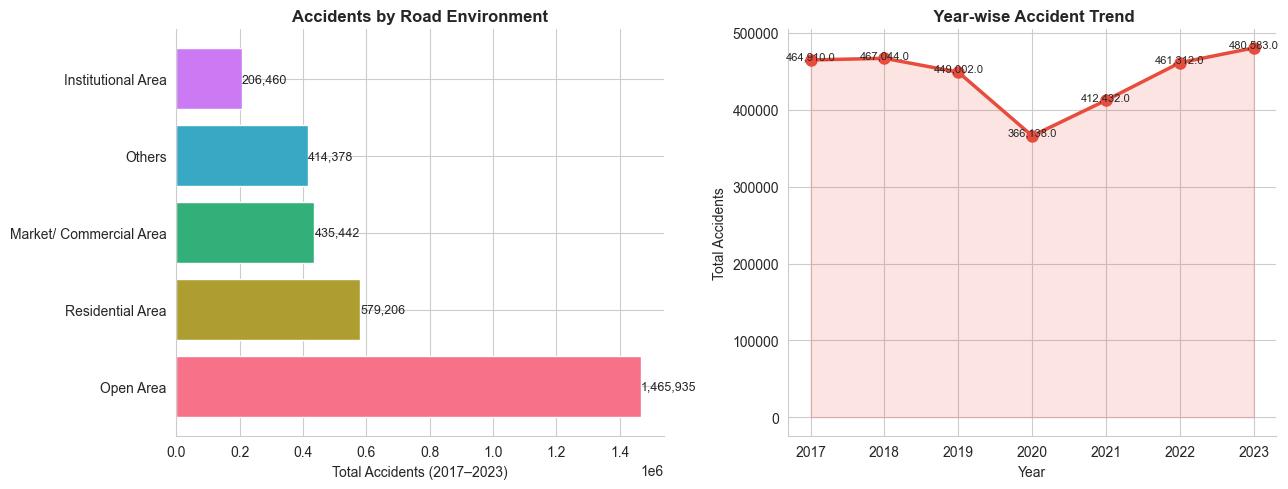

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accidents by Road Environment
env_stats = df.groupby('Road_Environment')['Total_Accidents'].sum().sort_values(ascending=False)
colors = sns.color_palette('husl', len(env_stats))
axes[0].barh(env_stats.index, env_stats.values, color=colors)
axes[0].set_xlabel('Total Accidents (2017–2023)')
axes[0].set_title('Accidents by Road Environment', fontweight='bold')
for i, v in enumerate(env_stats.values):
    axes[0].text(v + 500, i, f'{v:,.0f}', va='center', fontsize=9)

# Year-wise trend
year_trend = df.groupby('Year')['Total_Accidents'].sum()
axes[1].plot(year_trend.index, year_trend.values, marker='o', linewidth=2.5,
             color='#e74c3c', markersize=8)
axes[1].fill_between(year_trend.index, year_trend.values, alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Total Accidents')
axes[1].set_title(' Year-wise Accident Trend', fontweight='bold')
axes[1].set_xticks(year_trend.index)
for x, y in zip(year_trend.index, year_trend.values):
    axes[1].text(x, y + 500, f'{y:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
